# Notebook 07 — Distance Scaling Data Generation

**What this notebook does:**  
Generates Stim circuit data for d=3, d=5, and d=7 rotated surface codes.  
This is the foundation for testing whether our neural decoders scale with code distance —  
the single most important property a decoder must have for practical quantum computing.

**Why distance scaling matters:**  
A surface code only works if the logical error rate drops *exponentially* as d increases.  
Specifically: LER ∝ Λ^(-d/2) where Λ is the quality factor determined by physical noise + decoder.  
MWPM achieves this by construction. Whether NNs do too is an open research question.

**Circuit sizes:**
```
d=3 : 17 data qubits +  8 stabilisers = 26 total  |  72 detectors (9 rounds × 8)
d=5 : 41 data qubits + 24 stabilisers = 65 total  |  216 detectors (9 rounds × 24)
d=7 : 85 data qubits + 48 stabilisers = 133 total |  432 detectors (9 rounds × 48)
```

**Prerequisite:** None.  
```bash
pip install stim numpy
```

In [1]:
import numpy as np
import stim
import os

SEED   = 42
ROUNDS = 9
NOISE  = 0.001   # Training noise — same as before for fair comparison
np.random.seed(SEED)

print(f"Stim  : {stim.__version__}")
print(f"NumPy : {np.__version__}")

Stim  : 1.15.0
NumPy : 2.2.6


---
## 1. Circuit Inspector — Understand the Scaling

In [2]:
DISTANCES = [3, 5, 7]

print("Surface code scaling:")
print(f"  {'d':>4}  {'Qubits':>8}  {'Stabilisers/round':>18}  "
      f"{'Detectors (9r)':>16}  {'LSTM input shape':>20}")
print("-" * 80)

circuit_info = {}
for d in DISTANCES:
    circ   = stim.Circuit.generated(
        "surface_code:rotated_memory_z",
        rounds=ROUNDS, distance=d,
        after_clifford_depolarization=NOISE,
        after_reset_flip_probability=NOISE,
        before_measure_flip_probability=NOISE,
        before_round_data_depolarization=NOISE,
    )
    n_det   = circ.num_detectors
    n_stabs = n_det // ROUNDS
    circuit_info[d] = {'circuit': circ, 'n_det': n_det, 'n_stabs': n_stabs}
    print(f"  d={d}  {circ.num_qubits:>8,}  {n_stabs:>18,}  "
          f"{n_det:>16,}  ({ROUNDS}, {n_stabs}):>20")

print()
print("Note: LSTM input size (n_stabs) grows as d² — this is manageable.")
print("      Transformer attention cost is O(rounds²) — constant in d.")

Surface code scaling:
     d    Qubits   Stabilisers/round    Detectors (9r)      LSTM input shape
--------------------------------------------------------------------------------
  d=3        26                   8                72  (9, 8):>20
  d=5        64                  24               216  (9, 24):>20
  d=7       118                  48               432  (9, 48):>20

Note: LSTM input size (n_stabs) grows as d² — this is manageable.
      Transformer attention cost is O(rounds²) — constant in d.


---
## 2. Sample Training Data for Each Distance

In [3]:
TRAIN_SHOTS = 100_000
SWEEP_SHOTS = 50_000
NOISE_LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]

def sample_circuit(circuit, num_shots):
    sampler     = circuit.compile_sampler()
    raw_all     = np.array(sampler.sample(num_shots), dtype=np.bool_)
    m2d         = circuit.compile_m2d_converter()
    det, obs    = m2d.convert(measurements=raw_all, separate_observables=True)
    n_det       = det.shape[1]
    raw_syn     = raw_all[:, :n_det]    # syndrome columns only
    return (det.astype(np.float32),
            raw_syn.astype(np.float32),
            obs.squeeze().astype(np.float32))


for d in DISTANCES:
    print(f"\n{'='*55}")
    print(f"Distance d={d}")
    print('='*55)

    os.makedirs(f"data/d{d}", exist_ok=True)
    os.makedirs(f"data/d{d}/sweep", exist_ok=True)

    circ = circuit_info[d]['circuit']

    # Training data at p=0.001
    det, raw, obs = sample_circuit(circ, TRAIN_SHOTS)
    np.save(f"data/d{d}/detection_events.npy", det)
    np.save(f"data/d{d}/raw_measurements.npy", raw)
    np.save(f"data/d{d}/observable_flips.npy",  obs)

    print(f"  Training data saved:")
    print(f"    det : {det.shape}   LER={obs.mean():.4f}")
    print(f"    raw : {raw.shape}")

    # Sweep data
    print(f"  Sweep data:")
    for p in NOISE_LEVELS:
        sweep_circ = stim.Circuit.generated(
            "surface_code:rotated_memory_z",
            rounds=ROUNDS, distance=d,
            after_clifford_depolarization=p,
            after_reset_flip_probability=p,
            before_measure_flip_probability=p,
            before_round_data_depolarization=p,
        )
        det_s, raw_s, obs_s = sample_circuit(sweep_circ, SWEEP_SHOTS)
        tag = f"{int(p*10000):04d}"
        np.save(f"data/d{d}/sweep/det_p{tag}.npy", det_s)
        np.save(f"data/d{d}/sweep/raw_p{tag}.npy", raw_s)
        np.save(f"data/d{d}/sweep/obs_p{tag}.npy", obs_s)
        print(f"    p={p:.4f}  LER={obs_s.mean():.4f}")

print("\nAll distance data saved.")


Distance d=3
  Training data saved:
    det : (100000, 72)   LER=0.0531
    raw : (100000, 72)
  Sweep data:
    p=0.0005  LER=0.0271
    p=0.0010  LER=0.0549
    p=0.0020  LER=0.1020
    p=0.0050  LER=0.2172
    p=0.0100  LER=0.3429
    p=0.0200  LER=0.4529

Distance d=5
  Training data saved:
    det : (100000, 216)   LER=0.0929
    raw : (100000, 216)
  Sweep data:
    p=0.0005  LER=0.0501
    p=0.0010  LER=0.0908
    p=0.0020  LER=0.1706
    p=0.0050  LER=0.3187
    p=0.0100  LER=0.4328
    p=0.0200  LER=0.4925

Distance d=7
  Training data saved:
    det : (100000, 432)   LER=0.1273
    raw : (100000, 432)
  Sweep data:
    p=0.0005  LER=0.0680
    p=0.0010  LER=0.1259
    p=0.0020  LER=0.2198
    p=0.0050  LER=0.3841
    p=0.0100  LER=0.4739
    p=0.0200  LER=0.4935

All distance data saved.


---
## 3. MWPM Baseline for Each Distance

Generate MWPM results at all distances so we have the reference lines for notebook 08.

In [4]:
import pymatching

mwpm_by_distance = {}  # d → [(p, LER), ...]

print("MWPM sweep across distances")
for d in DISTANCES:
    print(f"\n  d={d}:")
    results = []
    for p in NOISE_LEVELS:
        circ = stim.Circuit.generated(
            "surface_code:rotated_memory_z",
            rounds=ROUNDS, distance=d,
            after_clifford_depolarization=p,
            after_reset_flip_probability=p,
            before_measure_flip_probability=p,
            before_round_data_depolarization=p,
        )
        dem      = circ.detector_error_model(decompose_errors=True)
        matching = pymatching.Matching.from_detector_error_model(dem)
        sampler  = circ.compile_detector_sampler()
        det_e, obs_e = sampler.sample(SWEEP_SHOTS, separate_observables=True)
        pred     = matching.decode_batch(np.array(det_e, dtype=np.bool_))
        ler      = float(np.any(pred != np.array(obs_e, dtype=np.bool_), axis=1).mean())
        results.append((p, ler))
        print(f"    p={p:.4f}  LER={ler:.5f}")
    mwpm_by_distance[d] = results
    np.save(f"results/mwpm_d{d}_sweep.npy", np.array(results))

print("\nSaved MWPM results for all distances.")

MWPM sweep across distances

  d=3:
    p=0.0005  LER=0.00044
    p=0.0010  LER=0.00190
    p=0.0020  LER=0.00806
    p=0.0050  LER=0.04834
    p=0.0100  LER=0.15078
    p=0.0200  LER=0.35056

  d=5:
    p=0.0005  LER=0.00004
    p=0.0010  LER=0.00022
    p=0.0020  LER=0.00200
    p=0.0050  LER=0.02636
    p=0.0100  LER=0.14678
    p=0.0200  LER=0.41024

  d=7:
    p=0.0005  LER=0.00000
    p=0.0010  LER=0.00006
    p=0.0020  LER=0.00048
    p=0.0050  LER=0.01318
    p=0.0100  LER=0.13540
    p=0.0200  LER=0.44276

Saved MWPM results for all distances.


---
## 4. Distance Scaling Preview — MWPM

Before training any NNs, visualise how MWPM scales —  
this is the target every NN decoder is trying to match.

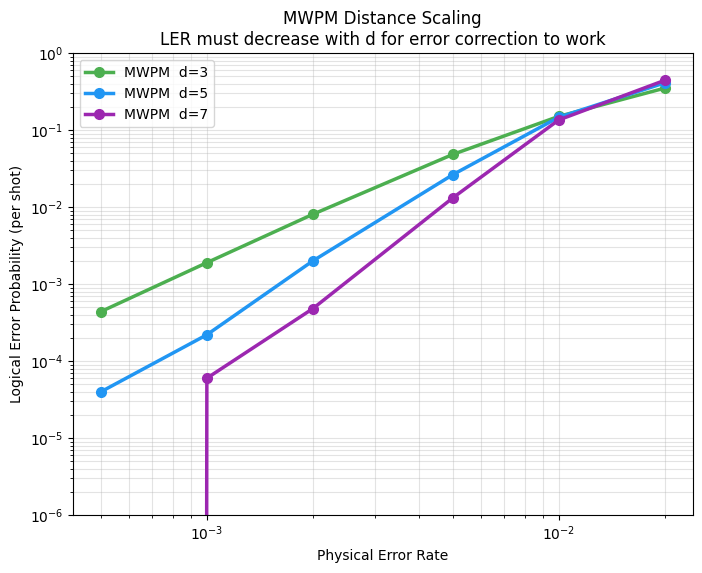

Saved → figures/07_mwpm_distance_scaling.png

Interpretation:
  Each higher distance should produce a LOWER LER line below the noise threshold.
  The crossing point where lines diverge is the error correction threshold (~1% for d=3 surface code).
  Run notebook 08 to train NNs and see if they show the same scaling.


In [5]:
import matplotlib.pyplot as plt

colors = {'3': '#4CAF50', '5': '#2196F3', '7': '#9C27B0'}

fig, ax = plt.subplots(figsize=(8, 6))

for d in DISTANCES:
    results = mwpm_by_distance[d]
    ps_d    = [r[0] for r in results]
    lers_d  = [r[1] for r in results]
    ax.plot(ps_d, lers_d, 'o-', color=colors[str(d)],
            lw=2.5, ms=7, label=f'MWPM  d={d}')

ax.loglog()
ax.set_ylim(1e-6, 1)
ax.grid(which='both', alpha=0.35)
ax.set_ylabel('Logical Error Probability (per shot)')
ax.set_xlabel('Physical Error Rate')
ax.set_title('MWPM Distance Scaling\n'
             'LER must decrease with d for error correction to work')
ax.legend(fontsize=10)

os.makedirs("figures", exist_ok=True)
fig.savefig('figures/07_mwpm_distance_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/07_mwpm_distance_scaling.png")
print()
print("Interpretation:")
print("  Each higher distance should produce a LOWER LER line below the noise threshold.")
print("  The crossing point where lines diverge is the error correction threshold (~1% for d=3 surface code).")
print("  Run notebook 08 to train NNs and see if they show the same scaling.")